In [1]:
# missingno는 결측치 시각화에 사용하는 라이브러리입니다.
# 현재 노트북에서는 직접 사용하지 않더라도, 결측치 분석을 위해 설치해 둡니다.
# -q 옵션은 설치 로그를 간단히 출력하게 합니다.
!pip install missingno -q

In [2]:
# numpy는 수치 계산을 위한 라이브러리
import numpy as np

# pandas는 CSV 파일 로드, 데이터프레임 처리, Feature Engineering에 사용
import pandas as pd

# matplotlib은 기본 시각화 라이브러리
import matplotlib.pyplot as plt

# seaborn은 matplotlib보다 보기 좋은 통계 그래프를 그릴 때 사용
import seaborn as sns

# seaborn 그래프의 스타일을 흰 배경 격자 스타일로 설정
sns.set_theme(style="whitegrid")

# 그래프 글자 크기를 조금 작게 설정
sns.set(font_scale=0.8)

# 경고 메시지 숨깁
import warnings
warnings.filterwarnings('ignore')

# matplotlib 그래프가 노트북 셀 아래에 바로 출력되도록 설정
%matplotlib inline

In [3]:
# 학습데이터 호출
df_train = pd.read_csv('./data/train.csv')

# 테스트 데이터 호출
df_test = pd.read_csv('./data/test.csv')

# 제출 양식 호출
submission = pd.read_csv('./data/sample_submission.csv')

# 학습데이터의 컬럼 구조와 형태 확인
df_train.head()

# 학습 데이터 행과 열 갯수 출력
print(df_train.shape)

# 테스트 데이터 행과 열 갯수 출력
print(df_test.shape)

(8693, 14)
(4277, 13)


In [4]:
# 학습 데이터의 컬럼 통계 요약을 확인
df_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [5]:
# 테스트 데이터의 컬럼 통계 요약을 확인
df_test.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


In [6]:
# 학습 데이터의 모든 컬럼을 하나씩 반복
for col in df_train.columns:

    # 현재 컬럼의 결측치 개수를 전체 행 개수로 나누어 결측치 비율을 계산
    # {:>10}은 컬럼명을 오른쪽 정렬해서 출력하기 위한 형식
    # {:.2f}%는 결측치 비율을 소수점 둘째 자리까지 출력
    msg = 'column: {:>10}\t Percent of NaN value: {:.2f}%'.format(col, 100 * (df_train[col].isnull().sum() / df_train[col].shape[0]))
    
    # 결측치 비율을 컬럼별로 출력
    print(msg)

column: PassengerId	 Percent of NaN value: 0.00%
column: HomePlanet	 Percent of NaN value: 2.31%
column:  CryoSleep	 Percent of NaN value: 2.50%
column:      Cabin	 Percent of NaN value: 2.29%
column: Destination	 Percent of NaN value: 2.09%
column:        Age	 Percent of NaN value: 2.06%
column:        VIP	 Percent of NaN value: 2.34%
column: RoomService	 Percent of NaN value: 2.08%
column:  FoodCourt	 Percent of NaN value: 2.11%
column: ShoppingMall	 Percent of NaN value: 2.39%
column:        Spa	 Percent of NaN value: 2.11%
column:     VRDeck	 Percent of NaN value: 2.16%
column:       Name	 Percent of NaN value: 2.30%
column: Transported	 Percent of NaN value: 0.00%


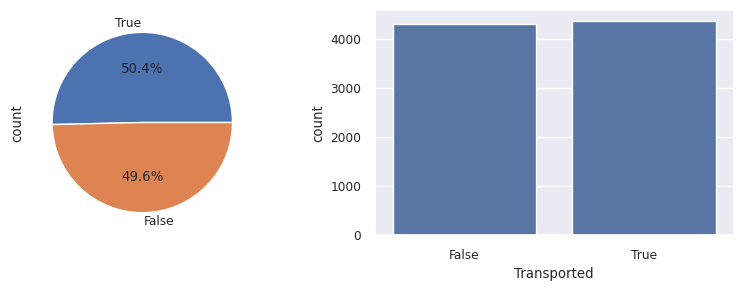

In [7]:
# 그래프 2개를 가로로 배치할 Figure와 Axes를 생성
f, ax = plt.subplots(1,2,figsize=(8,3))

# Transported 정답값의 비율을 파이차트로 시각화
df_train['Transported'].value_counts().plot.pie(
    autopct='%1.1f%%',
    ax=ax[0]
)

# Transported 정답값의 개수를 막대그래프로 시각화
sns.countplot(
    x='Transported',
    data=df_train,
    ax=ax[1]
)

plt.tight_layout()
plt.show()

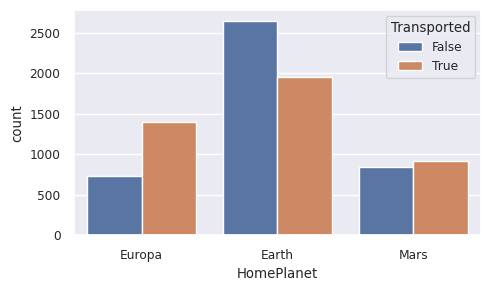

In [8]:
# HomePlanet과 Transported의 관계를 확인하기 위한 그래프
plt.figure(figsize=(5,3))

# HomePlanet에 따라 Transported 비율이 어떻게 다른지 시각화
sns.countplot(
    x='HomePlanet',
    hue='Transported',
    data=df_train
)

plt.tight_layout()
plt.show()

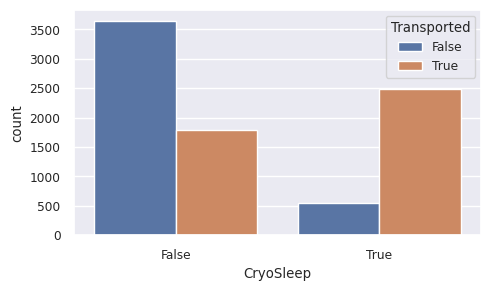

In [9]:
# CryoSleep과 Transported의 관계를 확인하기 위한 그래프
plt.figure(figsize=(5,3))

# CryoSleep에 따라 Transported 비율이 달라지는지 시각화
sns.countplot(
    x='CryoSleep',
    hue='Transported',
    data=df_train
)

plt.tight_layout()
plt.show()

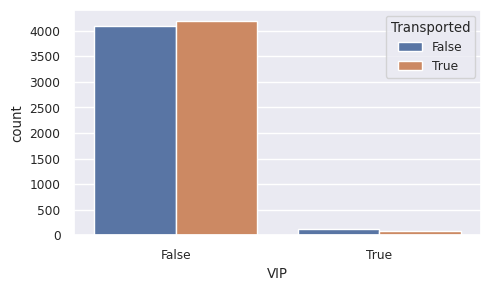

In [10]:
# VIP 여부와 Transported의 관계를 확인하기 위한 그래프
plt.figure(figsize=(5,3))

# VIP 여부에 따라 Transported 비율이 달라지는지 시각화
sns.countplot(
    x='VIP',
    hue='Transported',
    data=df_train
)

plt.tight_layout()
plt.show()

In [11]:
# train 데이터와 test 데이터에 동일한 Feature Engineering을 적용하기 위한 함수
def make_features(df):

    # 원본 데이터프레임 보존 장치
    df = df.copy()

    # PassengerId 분리
    df[['Group', 'PassengerNo']] = df['PassengerId'].str.split('_', expand=True)

    # 그룹은 숫자형 으로 변환
    df['Group'] = df['Group'].astype(int)

    # PassengerNo도 숫자형으로 변환
    df['PassengerNo'] = df['PassengerNo'].astype(int)

    # 그룹에 속한 승객 수
    df['GroupSize'] = df.groupby('Group')['PassengerId'].transform('count')

    # 혼자 탑승한 승객 수
    df['IsAlone'] = (df['GroupSize'] == 1).astype(int)

    # Cabin 분리
    cabin_split = df['Cabin'].str.split('/', expand=True)

    # cabin 첫번째 값은 Deck
    df['Deck'] = cabin_split[0]

    # cabin 두번째 값은 CabinNum
    df['CabinNum'] = pd.to_numeric(cabin_split[1], errors='coerce')

    # cabin 세번째 값은 Side
    df['Side'] = cabin_split[2]

    # CabinNum을 구간화 함
    df['CabinZone'] = pd.cut(
        df['CabinNum'],
        bins=[-1, 300, 600, 900, 1200, 1500, 2000],
        labels=['Z1', 'Z2', 'Z3', 'Z4', 'Z5', 'Z6']
    )

    # 이름에서 성 을 추출함
    df['LastName'] = df['Name'].str.split().str[-1]

    # 같은 성을 가진 승객 수
    df['FamilySize'] = df.groupby('LastName')['LastName'].transform('count')

    # 이름 없는 승객 결측치는 1 로 지정
    df['FamilySize'] = df['FamilySize'].fillna(1)

    # 소비 변수
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    # 소비 결측치는 0으로 채움
    df[spend_cols] = df[spend_cols].fillna(0)
    
    # 소비 금액 합산 = 총 소비금액
    df['TotalSpend'] = df[spend_cols].sum(axis=1)

    # 소비가 0인지 여부확인
    df['NoSpend'] = (df['TotalSpend'] == 0).astype(int)

    # FoodCourt + ShoppingMall 소비
    df['LuxurySpend'] = df['FoodCourt'] + df['ShoppingMall']

    # RoomService + Spa + VRDeck 소비
    df['ServiceSpend'] = df['RoomService'] + df['Spa'] + df['VRDeck']

    # TotalSpend 로그 변환
    df['LogSpend'] = np.log1p(df['TotalSpend'])

    # RoomService 로그 변환
    df['LogRoomService'] = np.log1p(df['RoomService'])

    # FoodCourt 로그 변환
    df['LogFoodCourt'] = np.log1p(df['FoodCourt'])

    # ShoppingMall 로그 변환
    df['LogShoppingMall'] = np.log1p(df['ShoppingMall'])

    # Spa 로그 변환
    df['LogSpa'] = np.log1p(df['Spa'])

    # VRDeck 로그 변환
    df['LogVRDeck'] = np.log1p(df['VRDeck'])

    # CryoSleep = True 이고 NoSpend = 1
    df['Cryo_NoSpend'] = (
        (df['CryoSleep'] == True) & 
        (df['NoSpend'] == 1)
    ).astype(int)

    # CryoSleep = True 이고 TotalSpend > 0
    df['Cryo_Spend'] = (
        (df['CryoSleep'] == True) & 
        (df['TotalSpend'] > 0)
    ).astype(int)

    # 그룹 인원당 평균 소비금액
    df['SpendPerPerson'] = df['TotalSpend'] / df['GroupSize']

    # 나이 구간화
    df['AgeGroup'] = pd.cut(
        df['Age'],
        bins=[-1, 12, 18, 30, 45, 60, 100],
        labels=['Child', 'Teen', 'Young', 'Adult', 'Senior', 'Old']
    )

    # 나이가 결측인지 여부확인
    df['AgeMissing'] = df['Age'].isna().astype(int)

    return df

In [12]:
# 학습 데이터에 Feature Engineering 함수를 적용
train_fe = make_features(df_train)

# 테스트 데이터에 Feature Engineering 함수를 적용
test_fe = make_features(df_test)

# Feature Engineering 결과의 상위 5개 행을 확인
train_fe.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,LogRoomService,LogFoodCourt,LogShoppingMall,LogSpa,LogVRDeck,Cryo_NoSpend,Cryo_Spend,SpendPerPerson,AgeGroup,AgeMissing
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.0,Adult,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,4.700480,2.302585,3.258097,6.309918,3.806662,0,0,736.0,Young,0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,3.784190,8.182280,0.000000,8.812248,3.912023,0,0,5191.5,Senior,0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,0.000000,7.157735,5.918894,8.110728,5.267858,0,0,2588.0,Adult,0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,5.717028,4.262680,5.023881,6.338594,1.098612,0,0,1091.0,Teen,0


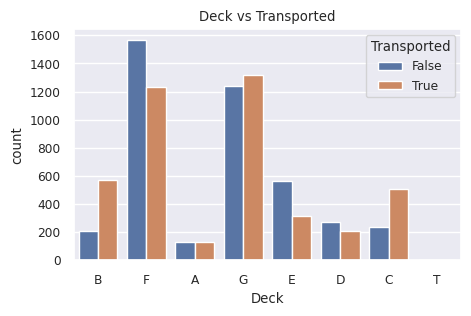

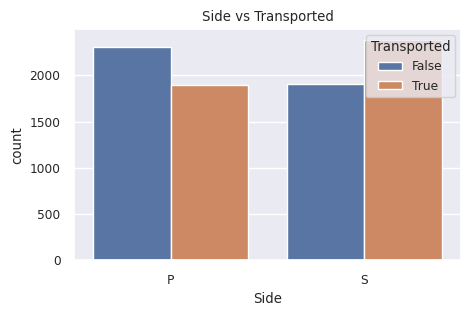

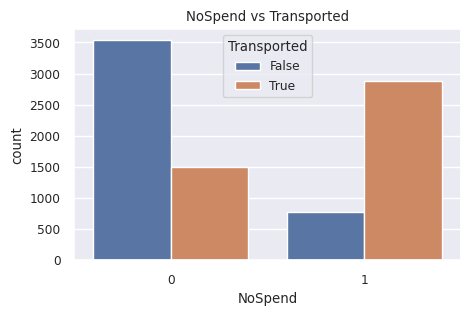

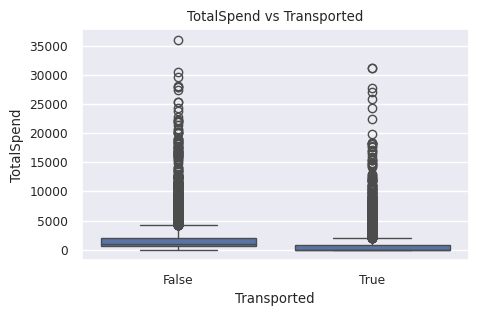

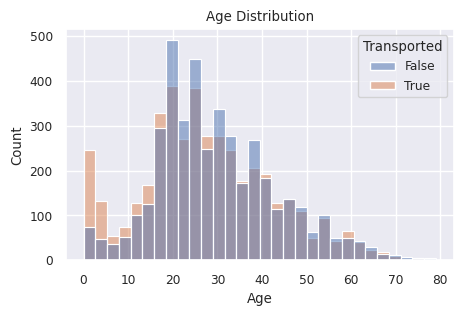

In [13]:
# Deck별 Transported 분포를 보기 위한 그래프
plt.figure(figsize=(5, 3))

# Deck에 따라 Transported 여부가 어떻게 달라지는지 시각화
sns.countplot(x='Deck', hue='Transported', data=train_fe)

plt.title('Deck vs Transported')
plt.show()

# Side별 Transported 분포를 보기 위한 그래프
plt.figure(figsize=(5, 3))

# Side에 따라 Transported 여부가 어떻게 달라지는지 시각화
sns.countplot(x='Side', hue='Transported', data=train_fe)

plt.title('Side vs Transported')
plt.show()

# NoSpend별 Transported 분포를 보기 위한 그래프
plt.figure(figsize=(5, 3))

# 소비가 전혀 없는 승객과 그렇지 않은 승객의 Transported 차이 시각화
sns.countplot(x='NoSpend', hue='Transported', data=train_fe)

plt.title('NoSpend vs Transported')
plt.show()

# TotalSpend와 Transported의 관계를 박스플롯으로 보기 위한 그래프
plt.figure(figsize=(5,3))

# Transported 여부에 따른 TotalSpend 분포 차이 시각화
sns.boxplot(x='Transported', y='TotalSpend', data=train_fe)

plt.title('TotalSpend vs Transported')
plt.show()

# Age 분포를 Transported 여부별로 확인하기 위한 그래프
plt.figure(figsize=(5,3))

# 나이 분포를 히스토그램으로 그리고 Transported 여부 시각화
sns.histplot(data=train_fe, x='Age', hue='Transported', bins=30)

plt.title('Age Distribution')
plt.show()

In [14]:
# train_test_split은 학습/검증 분리에 사용할 수 있는 함수
from sklearn.model_selection import train_test_split

# ColumnTransformer는 숫자형/범주형 컬럼에 서로 다른 전처리를 적용할 때 사용
from sklearn.compose import ColumnTransformer

# Pipeline은 전처리와 모델을 하나의 흐름으로 묶어주는 역할
from sklearn.pipeline import Pipeline

# SimpleImputer는 결측치를 특정 전략으로 채우는 전처리 도구
from sklearn.impute import SimpleImputer

# OneHotEncoder는 범주형 변수를 0/1 더미 변수로 변환
from sklearn.preprocessing import OneHotEncoder

# RandomForestClassifier는 앙상블 모델 중 하나
from sklearn.ensemble import RandomForestClassifier

# 모델이 맞혀야 하는 정답값
y = train_fe['Transported']

# 학습에 사용할 입력 변수
# 정답 컬럼과 식별자/문자열 원본 컬럼은 제거
X = train_fe.drop(
    columns=[
        'Transported',  #  정답은 제거
        'PassengerId',  #  단순 식별자 제거
        'Name',         #  FamilySize로 사용했으니 제거
        'Cabin',        #  Deck/CabinNum/Side로 분리했으므로 제거
        'LastName',     #  고유값이 많아 헷갈리니까 제거
        'Group',        #  PassengerId에서 만든 중간 컬럼이므로 제거
        'PassengerNo'   #  PassengerId에서 만든 중간 컬럼이므로 제거
    ],
    errors='ignore'     #  에러 무시
)

# 최종 예측에 사용할 테스트 입력 변수
# 정답 컬럼과 식별자/문자열 원본 컬럼은 제거
X_test = test_fe.drop(
    columns=[
        'PassengerId',  #  단순 식별자 제거
        'Name',         #  FamilySize로 사용했으니 제거
        'Cabin',        #  Deck/CabinNum/Side로 분리했으므로 제거
        'LastName',     #  고유값이 많아 헷갈리니까 제거
        'Group',        #  PassengerId에서 만든 중간 컬럼이므로 제거
        'PassengerNo'   #  PassengerId에서 만든 중간 컬럼이므로 제거
    ],
    errors='ignore'     #  에러 무시
)

In [15]:
# OneHotEncoder로 0/1 형태의 더미 변수로 변환할 컬럼 목록
cat_cols = [
    'HomePlanet',      #  출발 행성
    'CryoSleep',       #  냉동 수면 여부
    'Destination',     #  목적지
    'VIP',             #  VIP 여부
    'Deck',            #  Cabin에서 분리한 층/구역 정보
    'Side',            #  Cabin에서 분리한 좌/우 측면 정보
    'AgeGroup',        #  Age를 구간화한 연령대 변수
    'CabinZone'        #  CabinNum을 구간화한 객실 위치 변수
]

#  median으로 결측치를 채운 뒤 모델에 입력될 컬럼 목록
num_cols = [
    'Age',             #  승객 나이
    'RoomService',     #  룸서비스 소비 금액
    'FoodCourt',       #  푸드코트 소비 금액
    'ShoppingMall',    #  쇼핑몰 소비 금액
    'Spa',             #  스파 소비 금액
    'VRDeck',          #  VRDeck 소비 금액
    'GroupSize',       #  같은 PassengerId 그룹에 속한 승객 수
    'IsAlone',         #  혼자 탑승했는지 여부
    'FamilySize',      #  같은 성을 가진 승객 수
    'CabinNum',        #  Cabin에서 분리한 객실 번호
    'TotalSpend',      #  전체 소비 금액 합계
    'LuxurySpend',     #  FoodCourt + ShoppingMall 소비 합계
    'ServiceSpend',    #  RoomService + Spa + VRDeck 소비 합계
    'NoSpend',         #  총 소비가 0인지 여부
    'LogSpend',        #  TotalSpend를 로그 변환한 값
    'LogRoomService',  #  RoomService를 로그 변환한 값
    'LogFoodCourt',    #  FoodCourt를 로그 변환한 값
    'LogShoppingMall', #  ShoppingMall을 로그 변환한 값
    'LogSpa',          #  Spa를 로그 변환한 값
    'LogVRDeck',       #  VRDeck을 로그 변환한 값
    'Cryo_NoSpend',    #  CryoSleep이 True이면서 소비가 0인 경우
    'Cryo_Spend',      #  CryoSleep이 True이면서 소비가 있는 경우
    'SpendPerPerson',  #  그룹 인원 1명당 소비 금액
    'AgeMissing'       #  Age 결측 여부
] 

In [16]:
# 여러 앙상블 모델을 호출
from sklearn.ensemble import (
    RandomForestClassifier,      # 여러 결정트리를 bagging 방식으로 학습하는 모델
    ExtraTreesClassifier,        # RandomForest보다 더 무작위성이 큰 트리 앙상블 모델
    GradientBoostingClassifier,  # 약한 모델을 순차적으로 보완하는 boosting 모델
    VotingClassifier             # 여러 모델의 예측을 결합하는 앙상블 도구
)

# ColumnTransformer는 숫자형 컬럼과 범주형 컬럼에 다른 전처리를 적용
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',                             # 숫자형 전처리 단계의 이름
            SimpleImputer(strategy='median'),  # 결측치는 중앙값으로 채움
            num_cols                           # Cell 14에서 정의한 숫자형 컬럼 목록
        ),
        (
            'cat',                             # 범주형 전처리 단계의 이름
            Pipeline([                         # 범주형 전처리는 여러 단계를 순서대로 적용
                (
                    'imputer',                 # 범주형 결측치 처리 단계 이름
                    SimpleImputer(strategy='most_frequent')  # 결측치는 최빈값으로 채움
                ),
                (
                    'encoder',                 # 범주형 인코딩 단계 이름
                    OneHotEncoder(handle_unknown='ignore')  # 학습 때 없던 범주가 test에 나와도 무시함
                )
            ]),
            cat_cols                           # Cell 14에서 정의한 범주형 컬럼 목록
        )
    ]
)

# 모델 여러개를 합쳐 최종 예측
model = VotingClassifier(
    estimators=[
        (
            'rf',                       # 첫 번째 모델 이름
            RandomForestClassifier(
                n_estimators=1200,      # 생성할 트리 개수
                max_depth=14,           # 트리의 최대 깊이
                min_samples_leaf=2,     # 최소샘플값
                min_samples_split=4,    # 최소 샘플 수
                max_features='sqrt',    # 전체 Feature 중 일부만 사용
                random_state=42,        # 랜덤 시드
                n_jobs=-1               # CPU 풀 코어 사용
            )
        ),
        (
            'et',                       # 두 번째 모델 이름
            ExtraTreesClassifier(
                n_estimators=1800,      # 생성할 트리 개수
                max_depth=16,           # 트리 최대 깊이
                min_samples_leaf=2,     # 최소샘플값
                min_samples_split=4,    # 최소샘플 수
                max_features='sqrt',    # 전체 Feature 중 일부만 사용
                random_state=43,        # 랜덤 시드
                n_jobs=-1               # CPU 풀 코어 사용
            )
        ),
        (
            'gb',                       # 세 번째 모델 이름
            GradientBoostingClassifier(
                n_estimators=350,       # 순차적으로 학습할 모델 개수
                learning_rate=0.035,    # 각 모델이 최종 예측에 반영되는 비율
                max_depth=3,            # 트리의 깊이
                subsample=0.85,         # 각 단계에서 사용할 샘플 비율
                random_state=44         # 다른 모델들과 다른 시드를 사용함
            )
        )
    ],

    # 각 모델의 클래스 확률을 평균내어 최종 예측
    voting='soft',  

    # rf, et, gb 순서로 예측 확률 반영 비중을 설정합니다.
    weights=[2, 3, 2]  
)

# 전처리와 모델을 하나로 묶는 작업

clf = Pipeline([
    ('prep', preprocessor),  # 결측치 처리와 OneHotEncoding을 수행
    ('model', model)         # 전처리된 데이터를 VotingClassifier에 입력
])


In [17]:
# StratifiedKFold는 정답 비율을 유지하면서 데이터를 여러 Fold로 나눈다
# cross_val_score는 교차검증 점수를 계산
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 10-Fold 교차검증 설정
cv = StratifiedKFold(
    n_splits=10,      # 데이터를 10개 Fold로 나눕니다.
    shuffle=True,     # 데이터를 섞기
    random_state=42   # 섞는 방식이 매번 같도록 고정
)

# 교차검증으로 모델 성능을 측정
scores = cross_val_score(
    clf,                 # 전처리 + 모델이 들어 있는 Pipeline
    X,                   # 학습 입력 데이터
    y,                   # 학습 정답 데이터
    cv=cv,               # 위에서 만든 10-Fold 교차검증 설정
    scoring='accuracy',  # 정확도
    n_jobs=-1            # CPU 풀 코어 사용
)

print("CV Accuracy")

# 10개의 Fold에서 나온 정확도 배열을 출력
print(scores)

# 전체 Fold 정확도의 평균을 퍼센트로 출력
print(f"Mean Accuracy : {scores.mean()*100:.2f}%")


CV Accuracy
[0.79655172 0.83563218 0.81494253 0.79171461 0.81472957 0.81127733
 0.81588032 0.80897583 0.81242808 0.78250863]
Mean Accuracy : 80.85%


In [18]:
# cross_val_predict는 각 Fold의 검증 데이터 예측값을 모은다
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# accuracy_score는 예측값과 실제 정답을 비교해 정확도를 계산
from sklearn.metrics import accuracy_score

# clone은 같은 구조의 새 모델을 복제할 때 사용
# 교차검증 후 최종 학습용 모델을 새로 만들기 위해 사용
from sklearn.base import clone

# threshold 탐색용 10-Fold 교차검증 설정
cv = StratifiedKFold(
    n_splits=10,      # 데이터를 10개 Fold로 나눕니다.
    shuffle=True,     # 데이터를 섞기
    random_state=42   # 섞는 방식이 매번 같도록 고정.
)

# 각 샘플이 학습에 사용되지 않았던 Fold에서 예측된 확률
oof_proba = cross_val_predict(
    clf,                    # 전처리 + 모델 Pipeline
    X,                      # 학습 입력 데이터
    y,                      # 학습 정답 데이터
    cv=cv,                  # 위에서 만든 10-Fold 설정
    method='predict_proba', # 클래스 확률을 예측하도록 설정
    n_jobs=-1               # CPU 풀 코어 사용
)[:, 1]                     # Transported=True일 확률

# threshold 후보 설정
thresholds = np.arange(0.35, 0.65, 0.001)

# 처음에는 기본값 0.5로 시작
best_threshold = 0.5

# 처음에는 0으로 시작
best_score = 0

# 모든 threshold 후보를 하나씩 테스트
for t in thresholds:

    # 현재 threshold t보다 확률이 크면 True
    oof_pred = oof_proba > t

    # 현재 threshold에서의 OOF 정확도를 계산
    score = accuracy_score(y, oof_pred)

    # 현재 score가 지금까지의 최고 점수보다 좋으면 갱신
    if score > best_score:

        # 최고 OOF 정확도를 현재 score로 갱신
        best_score = score

        # 최고 threshold를 현재 t로 갱신
        best_threshold = t

# 가장 좋은 threshold 값을 출력
print("Best OOF Threshold:", best_threshold)

# 가장 좋은 OOF 정확도를 퍼센트로 출력
print(f"Best OOF Accuracy : {best_score * 100:.2f}%")

# 전체 학습 데이터로 새로 학습하기 위해서 최종 제출용 모델을 새로 복제
final_model = clone(clf)

# 최종 모델 학습
final_model.fit(X, y)


Best OOF Threshold: 0.44600000000000006
Best OOF Accuracy : 81.03%


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
# 테스트 데이터의 Transported=True 확률을 예측
test_proba = final_model.predict_proba(X_test)[:, 1]

# OOF에서 찾은 best_threshold를 기준으로 True/False 예측값
pred = test_proba > best_threshold

# sample_submission 형식의 Transported 컬럼에 예측값
submission['Transported'] = pred

# CSV 파일을 저장
submission.to_csv(
    'submission_threshold.csv',  # 저장할 제출 파일 이름
    index=False                  # 인덱스 컬럼은 저장 안함
)

# 제출 파일 상위 5개 행을 확인합니다.
submission.head()


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


# 회고

이번 프로젝트에서는 Spaceship Titanic 데이터를 활용하여 

승객의 Transported 여부를 예측하는 분류 모델을 구축하였다. 

처음에는 블로그에 적혀있는대로 데이터를 그대로 사용하여 모델을 학습하였으나 

기대한 수준의 성능을 얻지 못하였다. 

데이터의 의미를 분석하고 

Feature Engineering 및 전처리를 수행하여 모델 성능 향상을 시도하였다.

# 전처리 수행에 대한 논리적 근거
데이터 탐색 결과 PassengerId, Cabin, 소비 관련 변수들이 단순 문자열이나 개별 수치로 존재하고 있었기 때문에 

이를 그대로 사용하는 것보다 의미 있는 정보로 변환하는 과정이 필요하다고 판단하였다.

먼저 PassengerId를 활용하여 같은 그룹에 속한 승객 수를 나타내는 GroupSize를 생성하였다. 

실제로 가족이나 일행 단위의 이동 여부가 Transported 결과에 영향을 줄 수 있다고 판단하였기 때문이다.

Cabin 변수는 단일 문자열로 구성되어 있었기 때문에 

Deck, CabinNum, Side로 분리하였다. 

이를 통해 승객이 우주선의 어느 구역에 위치했는지 모델이 학습할 수 있도록 하였다.

소비 관련 변수(RoomService, FoodCourt, ShoppingMall, Spa, VRDeck)는 

각각 독립적으로 존재했지만 

승객의 전체 소비 성향을 나타내는 정보가 더 중요할 수 있다고 판단하여 

TotalSpend를 생성하였다. 

또한 LuxurySpend와 ServiceSpend를 추가 생성하여 소비 패턴을 보다 세분화하였다.

추가적으로 소비가 전혀 없는 승객을 나타내는 NoSpend 변수와 

소비 금액 분포의 왜곡을 줄이기 위한 LogSpend 변수를 생성하였다. 

이는 극단적으로 큰 소비 금액이 모델 학습에 과도한 영향을 주는 것을 방지하기 위함이다.

결측치의 경우 수치형 변수는 중앙값(Median)으로 대체하고 

범주형 변수는 최빈값(Most Frequent)으로 대체하였다. 

이후 범주형 변수는 One-Hot Encoding을 적용하여 머신러닝 모델이 처리할 수 있는 형태로 변환하였다.

# 모델 학습 성공 및 결과 분석 인사이트 도출
EDA 결과 CryoSleep 상태의 승객은 Transported 비율이 상대적으로 높게 나타났다. 

또한 소비 금액이 거의 없거나 매우 적은 승객들이 높은 Transported 비율을 보이는 경향을 확인하였다.

반면 RoomService, Spa, VRDeck 등에서 높은 소비를 기록한 승객은 

상대적으로 Transported 비율이 낮게 나타났다. 

이는 특정 생활 패턴이나 활동 특성이 목적 변수와 관련이 있을 가능성을 보여준다.

또한 Cabin 정보를 분리하여 분석한 결과 

Deck와 Side에 따라 Transported 비율에 차이가 존재하였으며, 

승객의 위치 정보가 중요한 예측 변수임을 확인할 수 있었다.

이번 프로젝트를 통해 단순히 모델을 복잡하게 만드는 것보다 

데이터의 의미를 이해하고 적절한 Feature Engineering을 수행하는 것이 

성능 향상에 더욱 중요하다는 점을 경험할 수 있었다. 

또한 전처리와 데이터 분석 과정이 모델 성능에 직접적인 영향을 미친다는 사실을 확인할 수 있었으며, 

향후 머신러닝 프로젝트에서도 데이터 이해를 우선적으로 수행해야 한다는 교훈을 얻을 수 있었다.

![](./png/2.png)